# World Cup 2026 Predictor - Data Exploration

This notebook explores the raw data, visualizes distributions, and analyzes historical trends.

In [34]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DIR, PROCESSED_DIR
from src.helpers import normalize_team_name

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Data

In [35]:
results_path = RAW_DIR / 'international_matches' / 'results.csv'
if results_path.exists():
    matches = pd.read_csv(results_path, parse_dates=['date'])
    matches['home_team'] = matches['home_team'].apply(normalize_team_name)
    matches['away_team'] = matches['away_team'].apply(normalize_team_name)
    print(f'Loaded {len(matches)} international matches')
    print(f'Date range: {matches["date"].min()} to {matches["date"].max()}')
    print(f'Unique teams: {len(set(matches["home_team"].unique()) | set(matches["away_team"].unique()))}')
else:
    print('Match data not found. Run the scraping pipeline first.')

Loaded 49477 international matches
Date range: 1872-11-30 00:00:00 to 2026-06-27 00:00:00
Unique teams: 336


In [36]:
matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [37]:
matches.describe()

,date,home_score,away_score
count,49477,49413.000000,49413.000000
mean,1994-05-22 13:38:00.550558,1.757230,1.181855
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-09-09 00:00:00,1.000000,0.000000
50%,2000-07-15 00:00:00,1.000000,1.000000
75%,2013-07-15 00:00:00,2.000000,2.000000
max,2026-06-27 00:00:00,31.000000,21.000000
std,NaN,1.774208,1.401981


## 2. Match Outcome Distribution

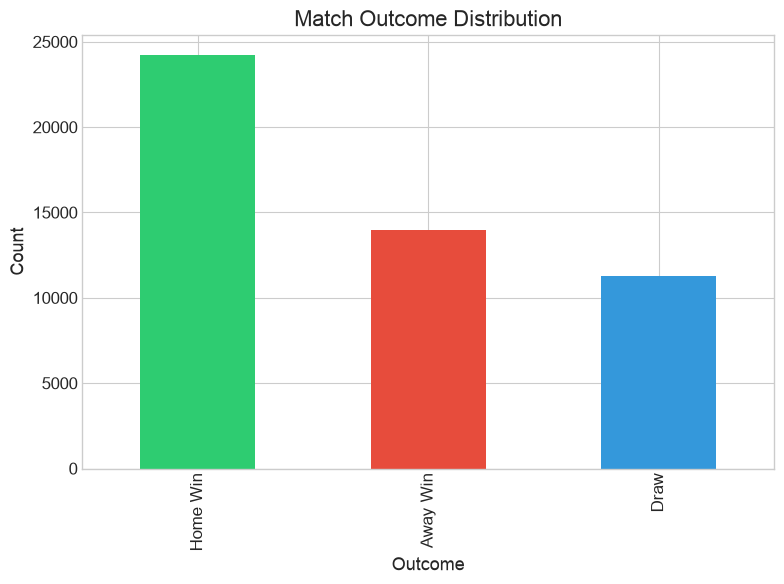

In [38]:
outcomes = []
for _, row in matches.iterrows():
    if row['home_score'] > row['away_score']:
        outcomes.append('Home Win')
    elif row['home_score'] < row['away_score']:
        outcomes.append('Away Win')
    else:
        outcomes.append('Draw')

matches['outcome'] = outcomes

fig, ax = plt.subplots(figsize=(8, 6))
matches['outcome'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#3498db'])
ax.set_title('Match Outcome Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Outcome')
plt.tight_layout()
plt.show()

## 3. World Cup Historical Performance

In [39]:
wc_matches = matches[matches['tournament'] == 'FIFA World Cup'].copy()
print(f'World Cup matches: {len(wc_matches)}')
print(f'World Cups: {sorted(wc_matches["date"].dt.year.unique())}')

World Cup matches: 1036
World Cups: [np.int32(1930), np.int32(1934), np.int32(1938), np.int32(1950), np.int32(1954), np.int32(1958), np.int32(1962), np.int32(1966), np.int32(1970), np.int32(1974), np.int32(1978), np.int32(1982), np.int32(1986), np.int32(1990), np.int32(1994), np.int32(1998), np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022), np.int32(2026)]


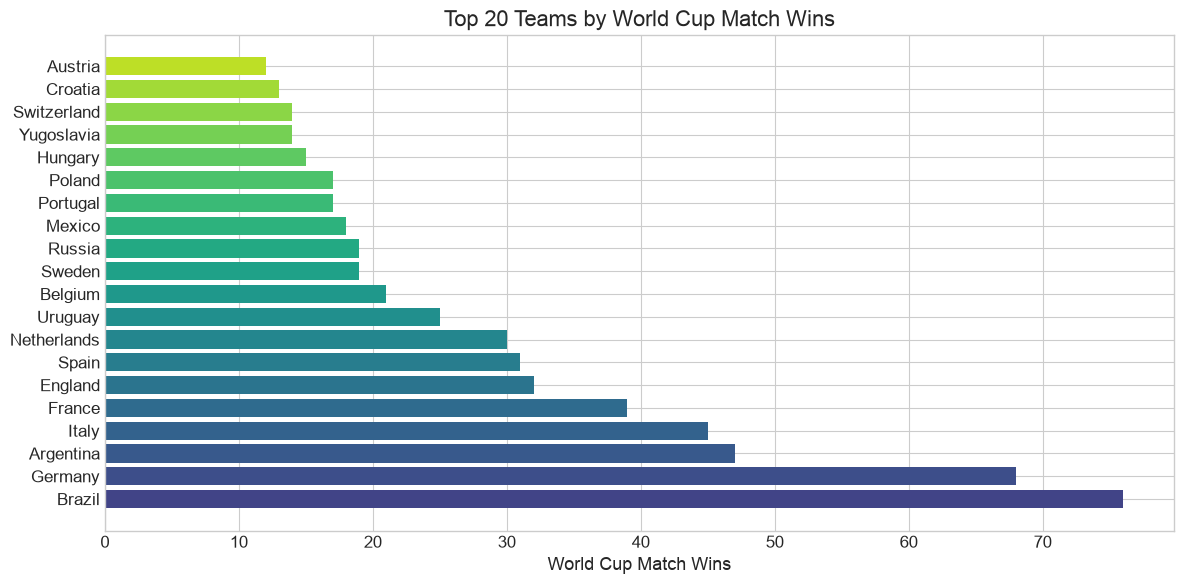

In [40]:
wc_wins = {}
for _, row in wc_matches.iterrows():
    if row['home_score'] > row['away_score']:
        wc_wins[row['home_team']] = wc_wins.get(row['home_team'], 0) + 1
    elif row['home_score'] < row['away_score']:
        wc_wins[row['away_team']] = wc_wins.get(row['away_team'], 0) + 1

top_wc_teams = sorted(wc_wins.items(), key=lambda x: -x[1])[:20]
teams, wins = zip(*top_wc_teams)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(teams)), wins, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(teams))))
ax.set_yticks(range(len(teams)))
ax.set_yticklabels(teams)
ax.set_xlabel('World Cup Match Wins')
ax.set_title('Top 20 Teams by World Cup Match Wins')
plt.tight_layout()
plt.show()

## 4. Goals per World Cup

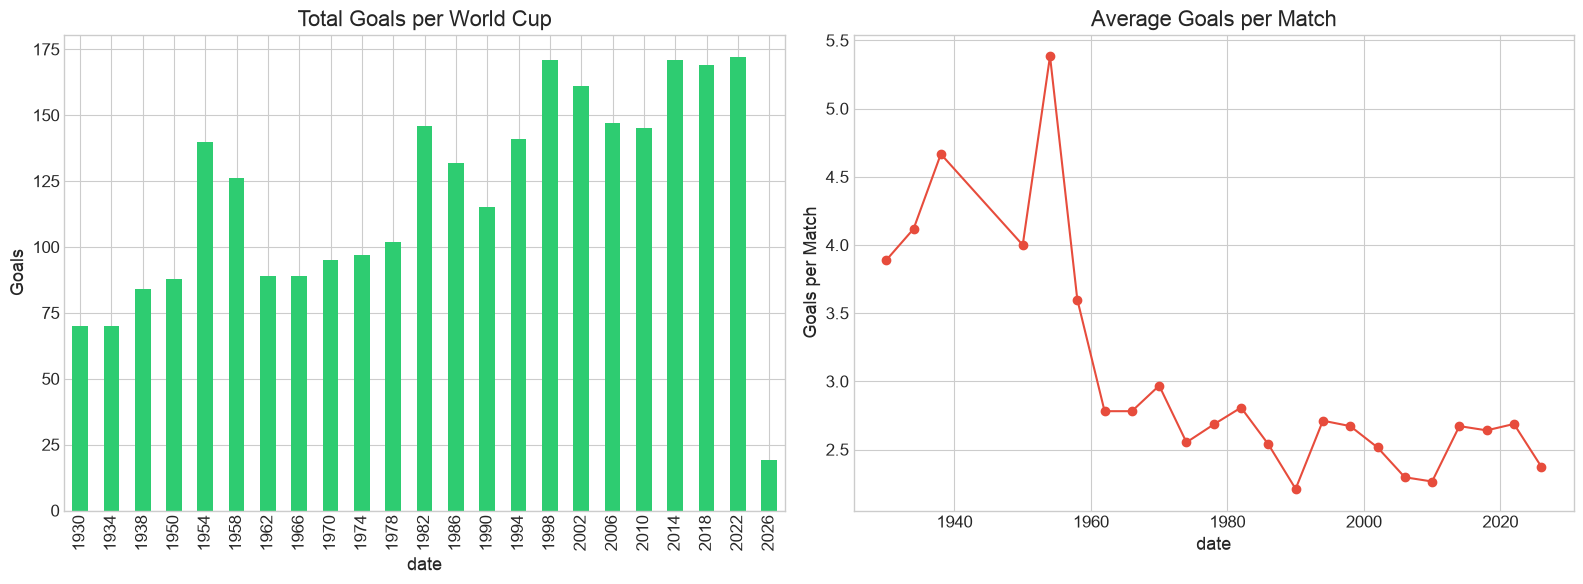

In [41]:
wc_matches['total_goals'] = wc_matches['home_score'] + wc_matches['away_score']
goals_per_wc = wc_matches.groupby(wc_matches['date'].dt.year)['total_goals'].agg(['sum', 'mean'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
goals_per_wc['sum'].plot(kind='bar', ax=ax1, color='#2ecc71')
ax1.set_title('Total Goals per World Cup')
ax1.set_ylabel('Goals')

goals_per_wc['mean'].plot(kind='line', ax=ax2, marker='o', color='#e74c3c')
ax2.set_title('Average Goals per Match')
ax2.set_ylabel('Goals per Match')

plt.tight_layout()
plt.show()

## 5. Elo Ratings

In [42]:
elo_path = PROCESSED_DIR / 'elo_ratings_current.parquet'
if elo_path.exists():
    elo_df = pd.read_parquet(elo_path)
    print(f'Loaded Elo ratings for {len(elo_df)} teams')
    print('\nTop 30:')
    print(elo_df.head(30).to_string(index=False))
else:
    print('Elo ratings not found. Run build_features.py first.')

Loaded Elo ratings for 4 teams

Top 30:
     team         elo
   Brazil 1047.459901
  Germany 1025.571782
Argentina 1000.772267
   France  926.196050


2026-06-16 08:58:27,355 [INFO] worldcup: Plotting Elo ratings...


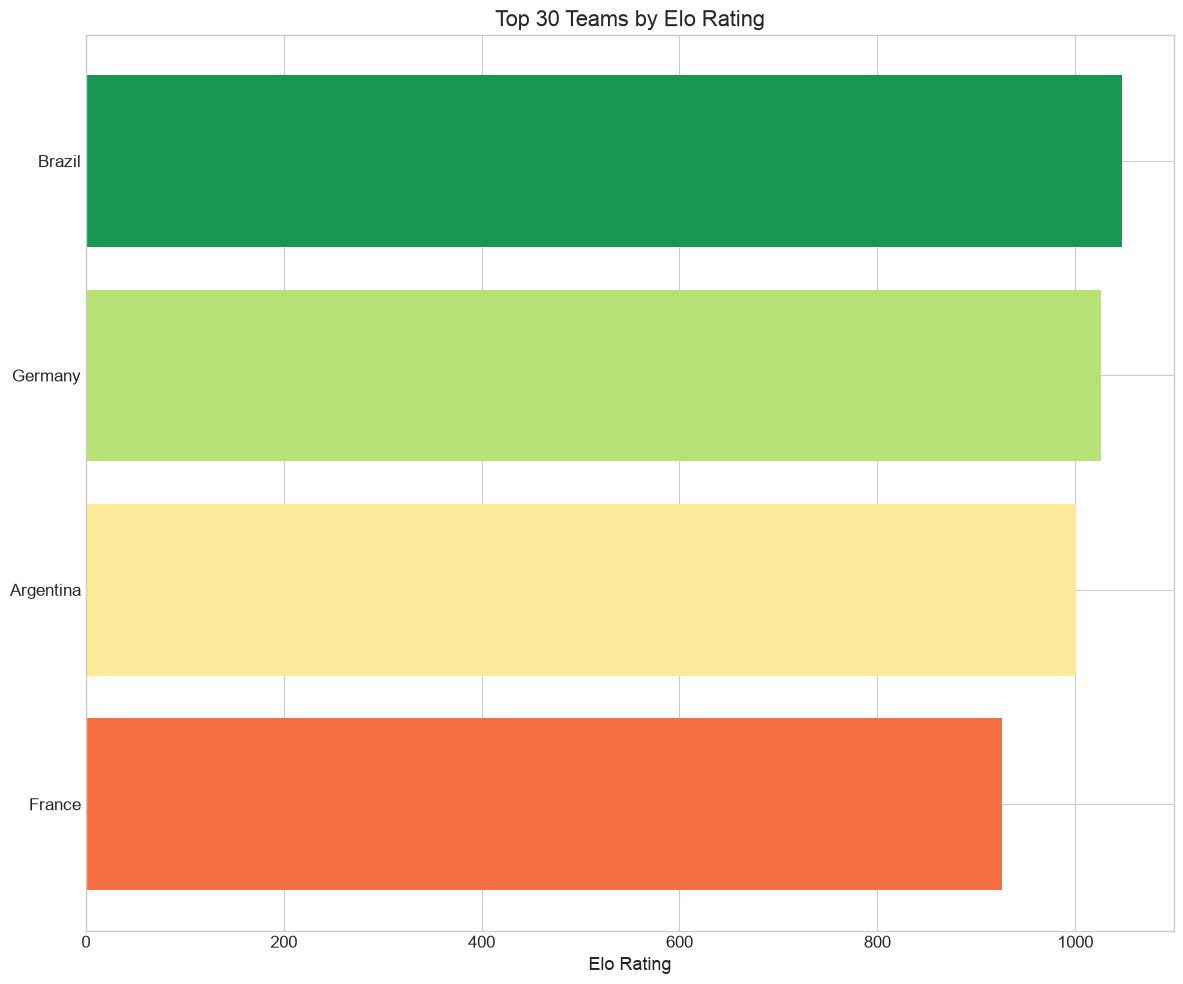

In [43]:
if elo_path.exists():
    from src.visualization.plots import plot_elo_ratings
    plot_elo_ratings(elo_df, top_n=30, save=False)
    plt.show()

## 6. FIFA Rankings Distribution

In [44]:
current_path = RAW_DIR / 'fifa_rankings_current.csv'
if current_path.exists():
    rankings = pd.read_csv(current_path)
    print(f'Loaded {len(rankings)} team rankings')
    print('\nTop 20:')
    print(rankings.head(20).to_string(index=False))
else:
    print('FIFA rankings not found. Run scrape_fifa_rankings.py first.')

Loaded 20 team rankings

Top 20:
 rank       country  total_points
    1     Argentina       1877.27
    2         Spain       1874.71
    3        France       1870.70
    4       England       1828.02
    5      Portugal       1767.85
    6        Brazil       1765.86
    7       Morocco       1755.10
    8   Netherlands       1753.57
    9       Belgium       1742.24
   10       Germany       1735.77
   11       Croatia       1714.87
   12         Italy       1704.73
   13      Colombia       1698.35
   14        Mexico       1687.48
   15       Senegal       1684.07
   16       Uruguay       1673.07
   17 United States       1671.23
   18         Japan       1661.58
   19   Switzerland       1650.06
   20          Iran       1619.58
